#  Mobile App Market Analysis
## Finding Profitable App Profiles for iOS & Android

**Context:** A mobile app company builds free apps monetized through in-app advertising.  
Revenue scales directly with user traffic, the more users engage, the more ad impressions are served.

**Objective:** Analyze both the Apple App Store and Google Play datasets to identify app categories that attract the largest user base, then recommend an app profile that can succeed on both platforms.

**Datasets:**
| Dataset | Source | Size | Year |
|---|---|---|---|
| Google Play Store | Kaggle | 10,000 apps | Aug 2018 |
| Apple App Store | Kaggle | 7,000 apps | Jul 2017 |

**Workflow:**
1. Load & explore the data
2. Clean: fix errors → drop duplicates → filter non-English & paid apps
3. Analyze genre distribution on each platform
4. Measure popularity via avg ratings (iOS) and avg installs (Android)
5. Visualize key findings
6. Recommend a winning app profile


## 1. Setup

In [21]:
import csv
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configure the visual style for all plots in the project
# 'whitegrid' adds horizontal/vertical lines for easier reading
# 'muted' uses a professional, soft color palette
sns.set_theme(style="whitegrid", palette="muted")

# Update global parameters to improve image quality and readability
# dpi=130 ensures high resolution for charts
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

print("Libraries ready")

Libraries ready


## 2. Load & Explore the Data

In [22]:
def load_csv(filepath):
    """Return (header, data_rows) from a CSV file."""
    with open(filepath, encoding="utf-8") as f:
        rows = list(csv.reader(f))
    return rows[0], rows[1:]

android_header, android = load_csv("googleplaystore.csv")
ios_header,     ios     = load_csv("AppleStore.csv")

print(f"Google Play  → {len(android):,} apps  |  columns: {len(android_header)}")
print(f"App Store    → {len(ios):,} apps  |  columns: {len(ios_header)}")
print()
print("Google Play columns:")
print(android_header)
print()
print("App Store columns:")
print(ios_header)


Google Play  → 10,841 apps  |  columns: 13
App Store    → 7,197 apps  |  columns: 16

Google Play columns:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

App Store columns:
['id', 'track_name', 'size_bytes', 'currency', 'price', 'rating_count_tot', 'rating_count_ver', 'user_rating', 'user_rating_ver', 'ver', 'cont_rating', 'prime_genre', 'sup_devices.num', 'ipadSc_urls.num', 'lang.num', 'vpp_lic']


In [23]:
def peek(dataset, header, n=3):
    """Print the first n rows of a dataset with column labels."""
    for row in dataset[:n]:
        ## zip() tells Python, "Give me each pair of (column name, row value)." for Readability
        for col, val in zip(header, row):
            print(f"  {col:<22} {val}")
        print()

print("── Google Play sample ──")
peek(android, android_header)

print("── App Store sample ──")
peek(ios, ios_header)


── Google Play sample ──
  App                    Photo Editor & Candy Camera & Grid & ScrapBook
  Category               ART_AND_DESIGN
  Rating                 4.1
  Reviews                159
  Size                   19M
  Installs               10,000+
  Type                   Free
  Price                  0
  Content Rating         Everyone
  Genres                 Art & Design
  Last Updated           January 7, 2018
  Current Ver            1.0.0
  Android Ver            4.0.3 and up

  App                    Coloring book moana
  Category               ART_AND_DESIGN
  Rating                 3.9
  Reviews                967
  Size                   14M
  Installs               500,000+
  Type                   Free
  Price                  0
  Content Rating         Everyone
  Genres                 Art & Design;Pretend Play
  Last Updated           January 15, 2018
  Current Ver            2.0.0
  Android Ver            4.0.3 and up

  App                    U Launcher Lite – 

## 3. Data Cleaning

### 3.1 Fix the Corrupted Row

The [Google Play dataset discussion on Kaggle](https://www.kaggle.com/lava18/google-play-store-apps/discussion/66015) flags row 10472 as corrupt, a missing value in the Category column shifted every subsequent field one position to the right, producing a nonsensical rating of 19 (max is 5).


In [24]:
# Inspect the bad row vs a valid one
print("Header:   ", android_header)
print("Bad row:  ", android[10472])
print("Good row: ", android[0])

# Remove it
del android[10472]
print(f"\nRemoved row 10472 → {len(android):,} rows remaining")


Header:    ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']
Bad row:   ['Life Made WI-Fi Touchscreen Photo Frame', '1.9', '19', '3.0M', '1,000+', 'Free', '0', 'Everyone', '', 'February 11, 2018', '1.0.19', '4.0 and up']
Good row:  ['Photo Editor & Candy Camera & Grid & ScrapBook', 'ART_AND_DESIGN', '4.1', '159', '19M', '10,000+', 'Free', '0', 'Everyone', 'Art & Design', 'January 7, 2018', '1.0.0', '4.0.3 and up']

Removed row 10472 → 10,840 rows remaining


### 3.2 Remove Duplicate Entries

Some apps appear multiple times because the data was scraped at different points in time. Rather than dropping duplicates randomly, we keep the entry with the **highest review count**  a higher count means more recent and more reliable data.


In [25]:
# Count duplicates
seen, duplicates = set(), []
for app in android:
    name = app[0]
    if name in seen:
        duplicates.append(name)
    else:
        seen.add(name)

print(f"Duplicate entries found: {len(duplicates):,}")
print(f"Example duplicates: {duplicates[:5]}")


Duplicate entries found: 1,181
Example duplicates: ['Quick PDF Scanner + OCR FREE', 'Box', 'Google My Business', 'ZOOM Cloud Meetings', 'join.me - Simple Meetings']


In [26]:
# Build a dict: app name → max review count
reviews_max = {}
for app in android:
    name = app[0]
    try:
        reviews = float(app[3])

        # if there's Text or Special Characters in a number column
    except ValueError:
        continue
    if name not in reviews_max or reviews_max[name] < reviews:
        reviews_max[name] = reviews

print(f"Unique apps (expected 9659): {len(reviews_max):,}")


Unique apps (expected 9659): 9,659


In [27]:
# Keep only the highest-review entry per app
android_clean, already_added = [], []
for app in android:
    name = app[0]
    try:
        n_reviews = float(app[3])
    except ValueError:
        continue
    # get() is a safe way to access key in dec in case there's no key with this name
    if reviews_max.get(name) == n_reviews and name not in already_added:
        android_clean.append(app)
        already_added.append(name)

print(f"Clean Android dataset: {len(android_clean):,} apps")


Clean Android dataset: 9,659 apps


### 3.3 Keep English-Language Apps Only

We filter out apps not targeting English speakers. We use a heuristic: if an app name contains **more than 3 characters outside the standard ASCII range** (0–127), we consider it non-English. This threshold prevents us from accidentally discarding English apps that use emojis or special symbols (™, –, etc.).


In [28]:
def is_english(name):
    """Return True if the app name appears to be English (≤ 3 non-ASCII chars)."""
    non_ascii = sum(1 for c in name if ord(c) > 127)
    return non_ascii <= 3

# Quick sanity check
tests = [
    ("Instagram",           True),
    ("爱奇艺PPS -《欢乐颂2》",   False),
    ("Docs To Go™ Free",    True),
    ("Instachat 😜",        True),
]
for name, expected in tests:
    result = is_english(name)
    status = "✓" if result == expected else "✗"
    print(f"  {status} is_english({name!r}) = {result}")


  ✓ is_english('Instagram') = True
  ✓ is_english('爱奇艺PPS -《欢乐颂2》') = False
  ✓ is_english('Docs To Go™ Free') = True
  ✓ is_english('Instachat 😜') = True


In [29]:
android_english = [a for a in android_clean if is_english(a[0])]
ios_english     = [a for a in ios           if is_english(a[1])]

print(f"Android after English filter: {len(android_english):,}")
print(f"iOS     after English filter: {len(ios_english):,}")


Android after English filter: 9,614
iOS     after English filter: 6,183


### 3.4 Isolate Free Apps

Since our company only builds free apps, we drop all paid apps from both datasets.


In [30]:
android_final = [a for a in android_english if a[7] == "0"]
ios_final     = [a for a in ios_english     if a[4] == "0.0"]

print(f"Final Android dataset: {len(android_final):,} free apps")
print(f"Final iOS dataset:     {len(ios_final):,} free apps")


Final Android dataset: 8,864 free apps
Final iOS dataset:     3,222 free apps


## 4. Genre Distribution Analysis

In [31]:
def freq_table(dataset, col_index):
    """Return {category: percentage} for a given column."""
    counts = {}
    for row in dataset:
        val = row[col_index]
        counts[val] = counts.get(val, 0) + 1
    total = len(dataset)
    return {k: v / total * 100 for k, v in counts.items()}

def sorted_table(dataset, col_index, top_n=None):
    """Return freq_table results sorted descending by percentage."""
    table = freq_table(dataset, col_index)
    result = sorted(table.items(), key=lambda x: x[1], reverse=True)
    return result[:top_n] if top_n else result


### 4.1 App Store — Genre Distribution

More than half of free English iOS apps are games, followed by entertainment and photo/video. Practical-utility categories (education, productivity, finance) are comparatively rare.

> **Insight:** High supply of fun apps doesn't necessarily mean high demand — we need to check actual user engagement numbers.


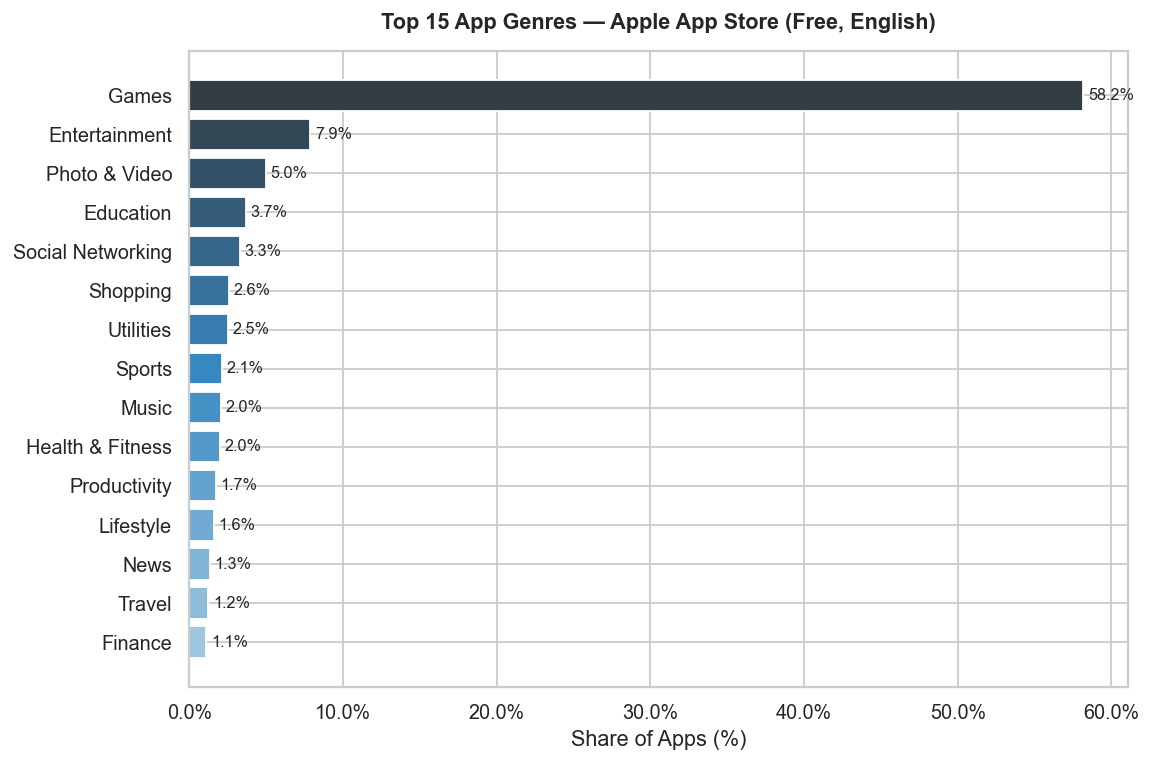

Chart saved.


In [32]:
ios_genres = sorted_table(ios_final, 11, top_n=15)
labels, values = zip(*ios_genres)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(labels[::-1], values[::-1],
               color=sns.color_palette("Blues_d", len(labels)))
ax.set_xlabel("Share of Apps (%)")
ax.set_title("Top 15 App Genres — Apple App Store (Free, English)", fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

for bar, val in zip(bars, values[::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("ios_genre_distribution.png", bbox_inches="tight")
plt.show()
print("Chart saved.")


### 4.2 Google Play — Category Distribution

Google Play has a more balanced mix. Family and tools categories are dominant, and practical apps (business, productivity, lifestyle) have stronger representation compared to the App Store.


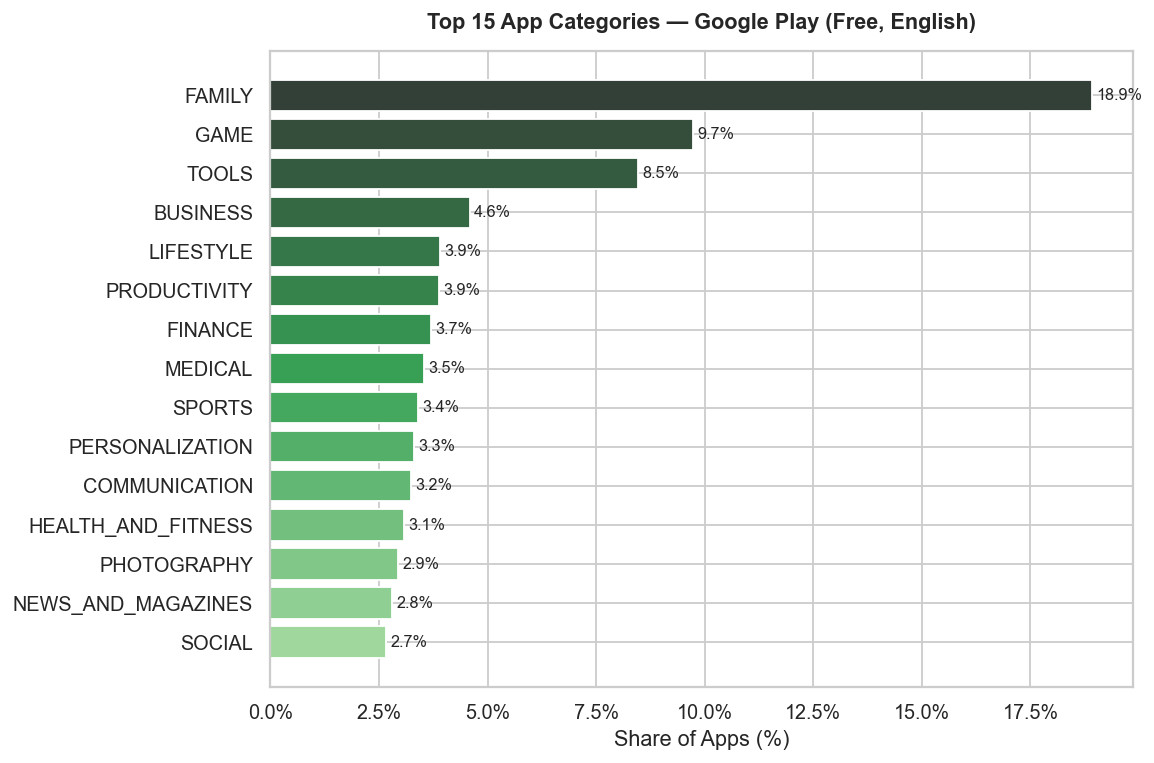

Chart saved.


In [33]:
android_cats = sorted_table(android_final, 1, top_n=15)
labels_a, values_a = zip(*android_cats)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(labels_a[::-1], values_a[::-1],
               color=sns.color_palette("Greens_d", len(labels_a)))
ax.set_xlabel("Share of Apps (%)")
ax.set_title("Top 15 App Categories — Google Play (Free, English)", fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

for bar, val in zip(bars, values_a[::-1]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("android_category_distribution.png", bbox_inches="tight")
plt.show()
print("Chart saved.")


### 4.3 Fun vs. Practical — Platform Comparison

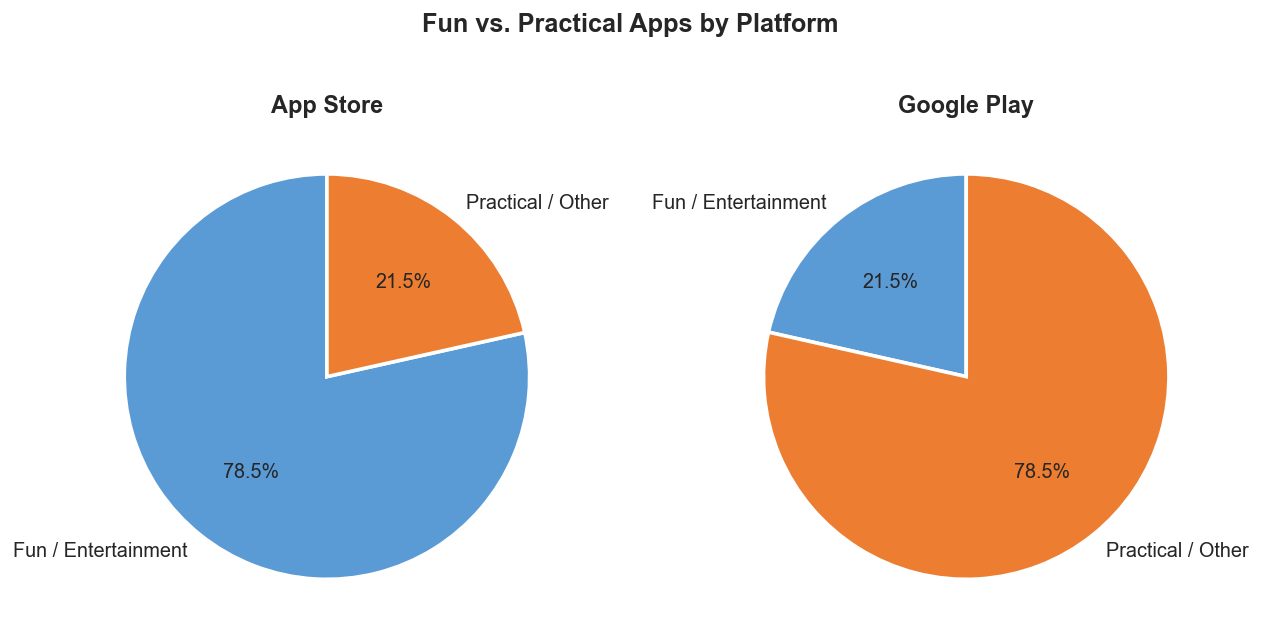

In [34]:
# Fun apps on iOS (games, entertainment, photo & video, music, social)
FUN_IOS = {"Games", "Entertainment", "Photo & Video", "Music", "Social Networking",
           "Sports", "Action", "Adventure"}
# Fun apps on Android
FUN_AND = {"GAME", "ENTERTAINMENT", "MUSIC_AND_AUDIO", "SOCIAL", "SPORTS",
           "VIDEO_PLAYERS", "PHOTOGRAPHY"}

ios_genre_pct   = freq_table(ios_final, 11)
ios_fun_pct     = sum(v for k, v in ios_genre_pct.items() if k in FUN_IOS)

android_cat_pct = freq_table(android_final, 1)
and_fun_pct     = sum(v for k, v in android_cat_pct.items() if k in FUN_AND)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (fun, platform) in zip(axes,
        [(ios_fun_pct, "App Store"), (and_fun_pct, "Google Play")]):
    ax.pie(
        [fun, 100 - fun],
        labels=["Fun / Entertainment", "Practical / Other"],
        autopct="%1.1f%%",
        startangle=90,
        colors=["#5B9BD5", "#ED7D31"],
        wedgeprops=dict(edgecolor="white", linewidth=2),
    )
    ax.set_title(platform, fontweight="bold", fontsize=13)

fig.suptitle("Fun vs. Practical Apps by Platform", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fun_vs_practical.png", bbox_inches="tight")
plt.show()


## 5. Popularity Analysis

### 5.1 Average User Ratings by Genre — App Store

The App Store doesn't expose install counts, so we use **total rating count** as a proxy for user reach.


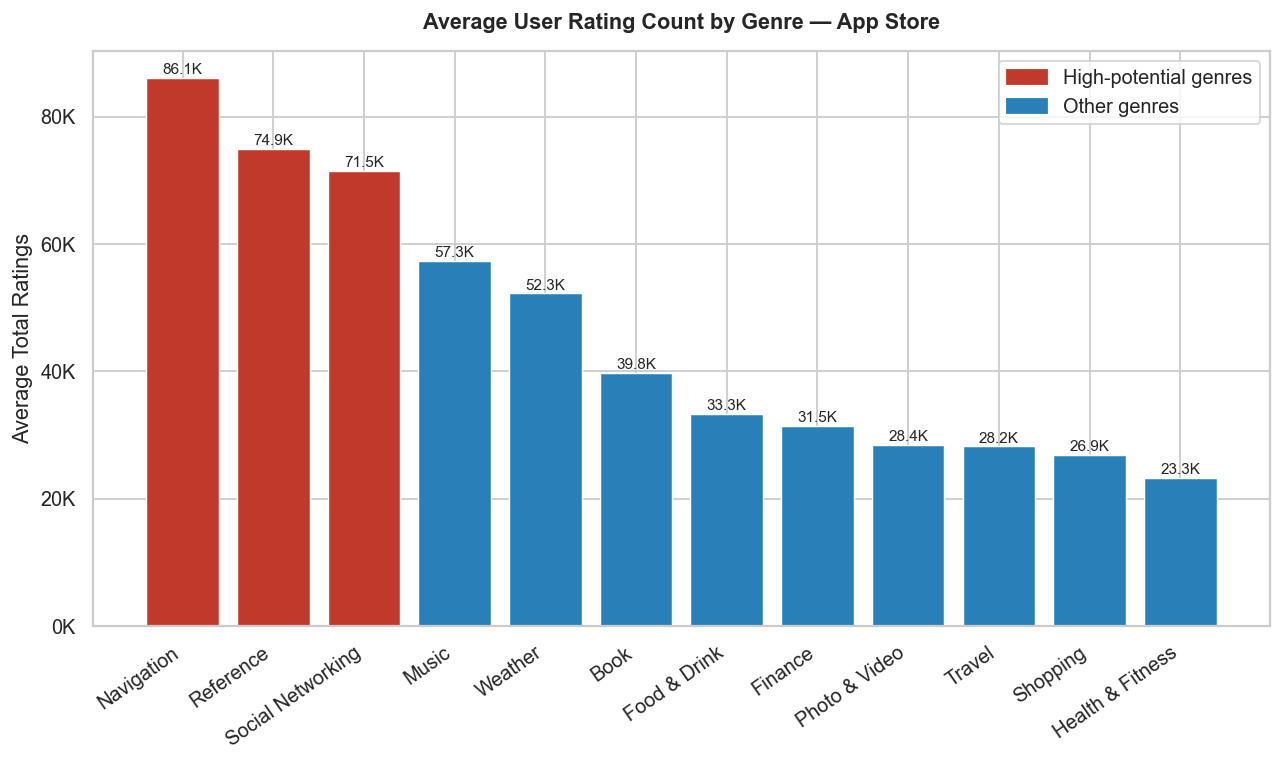

In [35]:
genres_ios = freq_table(ios_final, 11)
ios_genre_avg = {}
for genre in genres_ios:
    ratings = [float(a[5]) for a in ios_final if a[11] == genre]
    ios_genre_avg[genre] = sum(ratings) / len(ratings)

top_ios = sorted(ios_genre_avg.items(), key=lambda x: x[1], reverse=True)[:12]
labels_t, values_t = zip(*top_ios)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#c0392b" if l in {"Navigation", "Reference", "Social Networking"}
          else "#2980b9" for l in labels_t]
bars = ax.bar(labels_t, values_t, color=colors, edgecolor="white", linewidth=0.8)

ax.set_ylabel("Average Total Ratings")
ax.set_title("Average User Rating Count by Genre — App Store", fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
plt.xticks(rotation=35, ha="right")

for bar, val in zip(bars, values_t):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 600,
            f"{val/1000:.1f}K", ha="center", fontsize=8.5)

ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color="#c0392b", label="High-potential genres"),
    plt.Rectangle((0,0),1,1, color="#2980b9", label="Other genres"),
], loc="upper right")

plt.tight_layout()
plt.savefig("ios_avg_ratings.png", bbox_inches="tight")
plt.show()


> **Outlier warning:** Navigation, Social Networking, and Music averages are heavily skewed by a handful of giants (Google Maps, Waze, Facebook, Spotify). The "Reference" genre is skewed by the Bible and Dictionary.com.

Let's verify this for the Reference genre:


In [36]:
print("Reference genre apps (sorted by rating count):")
ref_apps = [(a[1], int(float(a[5]))) for a in ios_final if a[11] == "Reference"]
for name, count in sorted(ref_apps, key=lambda x: -x[1])[:10]:
    print(f"  {name:<40} {count:>10,}")


Reference genre apps (sorted by rating count):
  Bible                                       985,920
  Dictionary.com Dictionary & Thesaurus       200,047
  Dictionary.com Dictionary & Thesaurus for iPad     54,175
  Google Translate                             26,786
  Muslim Pro: Ramadan 2017 Prayer Times, Azan, Quran     18,418
  New Furniture Mods - Pocket Wiki & Game Tools for Minecraft PC Edition     17,588
  Merriam-Webster Dictionary                   16,849
  Night Sky                                    12,122
  City Maps for Minecraft PE - The Best Maps for Minecraft Pocket Edition (MCPE)      8,535
  LUCKY BLOCK MOD ™ for Minecraft PC Edition - The Best Pocket Wiki & Mods Installer Tools      4,693


### 5.2 Average Installs by Category — Google Play

Google Play includes install counts (as open-ended ranges like "1,000,000+"). We treat the floor of each range as the actual number — good enough for ranking categories.


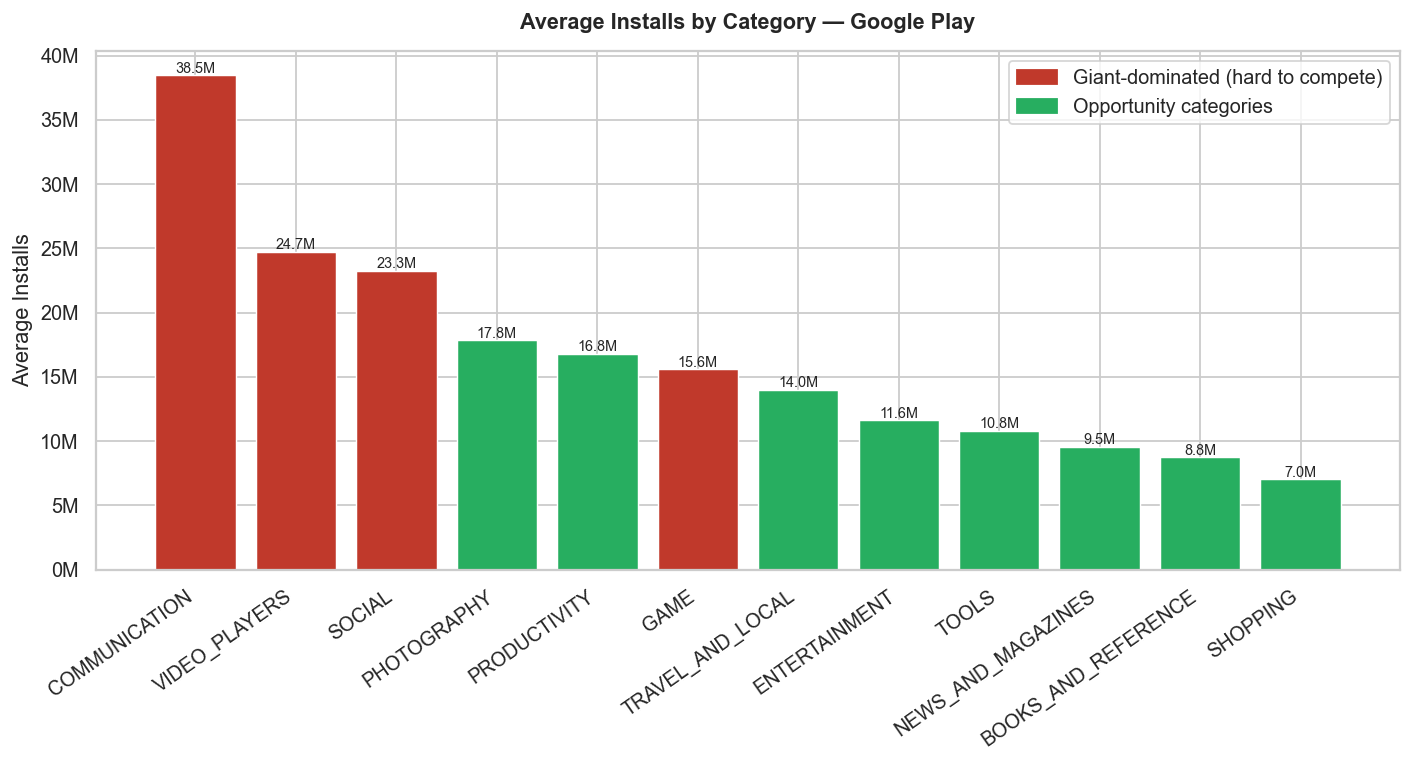

In [37]:
categories_android = freq_table(android_final, 1)
android_cat_avg = {}
for cat in categories_android:
    installs = []
    for app in android_final:
        if app[1] == cat:
            try:
                n = float(app[5].replace(",", "").replace("+", ""))
                installs.append(n)
            except ValueError:
                pass
    if installs:
        android_cat_avg[cat] = sum(installs) / len(installs)

top_android = sorted(android_cat_avg.items(), key=lambda x: x[1], reverse=True)[:12]
labels_an, values_an = zip(*top_android)

SATURATED = {"COMMUNICATION", "VIDEO_PLAYERS", "SOCIAL", "GAME"}
colors_an = ["#c0392b" if l in SATURATED else "#27ae60" for l in labels_an]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(labels_an, values_an, color=colors_an, edgecolor="white", linewidth=0.8)
ax.set_ylabel("Average Installs")
ax.set_title("Average Installs by Category — Google Play", fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
plt.xticks(rotation=35, ha="right")

for bar, val in zip(bars, values_an):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200_000,
            f"{val/1e6:.1f}M", ha="center", fontsize=8)

ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color="#c0392b", label="Giant-dominated (hard to compete)"),
    plt.Rectangle((0,0),1,1, color="#27ae60", label="Opportunity categories"),
], loc="upper right")

plt.tight_layout()
plt.savefig("android_avg_installs.png", bbox_inches="tight")
plt.show()


### 5.3 Deep Dive — Books & Reference Category

Both platforms show **Books & Reference** as a promising niche:
- App Store: Reference ranks **#2** by average ratings
- Google Play: BOOKS_AND_REFERENCE has a solid **8.7M** average installs

Let's look at which apps in this space are moderately popular (not giant-skewed):


In [38]:
print("── Google Play: Books & Reference (mid-tier installs) ──\n")
mid_tier = {"1,000,000+", "5,000,000+", "10,000,000+", "50,000,000+"}
for app in android_final:
    if app[1] == "BOOKS_AND_REFERENCE" and app[5] in mid_tier:
        print(f"  {app[0]:<45} {app[5]}")

print("\n── App Store: Reference apps (top 10 by ratings) ──\n")
ref_apps_all = [(a[1], int(float(a[5]))) for a in ios_final if a[11] == "Reference"]
for name, count in sorted(ref_apps_all, key=lambda x: -x[1])[:10]:
    print(f"  {name:<45} {count:>10,} ratings")


── Google Play: Books & Reference (mid-tier installs) ──

  Wikipedia                                     10,000,000+
  Cool Reader                                   10,000,000+
  Book store                                    1,000,000+
  FBReader: Favorite Book Reader                10,000,000+
  Free Books - Spirit Fanfiction and Stories    1,000,000+
  AlReader -any text book reader                5,000,000+
  FamilySearch Tree                             1,000,000+
  Cloud of Books                                1,000,000+
  ReadEra – free ebook reader                   1,000,000+
  Ebook Reader                                  5,000,000+
  Read books online                             5,000,000+
  eBoox: book reader fb2 epub zip               1,000,000+
  All Maths Formulas                            1,000,000+
  Ancestry                                      5,000,000+
  HTC Help                                      10,000,000+
  Moon+ Reader                                  10,00

### 5.4 Cross-Platform Opportunity Map

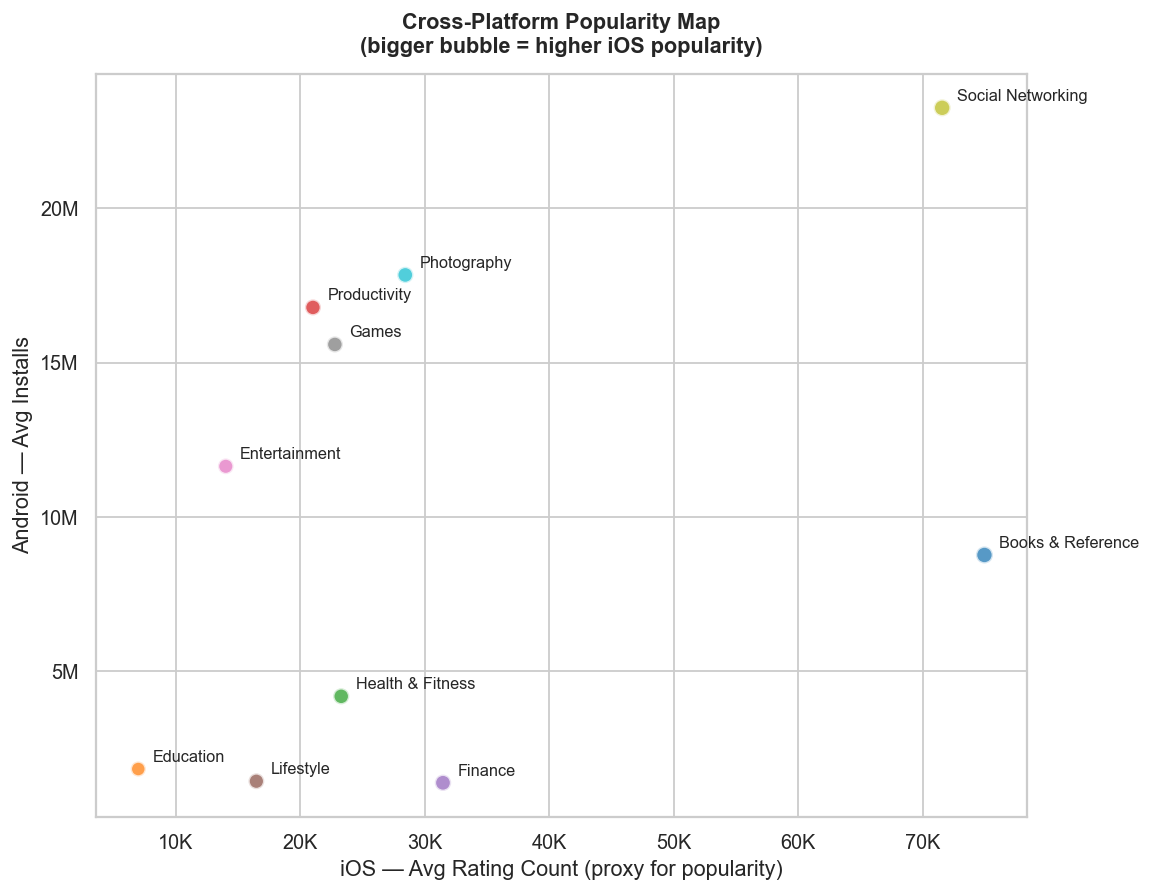

In [39]:
# Map Android categories to comparable iOS genres
CROSS_PLATFORM = {
    "BOOKS_AND_REFERENCE": ("Reference", "Books & Reference"),
    "EDUCATION":           ("Education", "Education"),
    "HEALTH_AND_FITNESS":  ("Health & Fitness", "Health & Fitness"),
    "PRODUCTIVITY":        ("Productivity", "Productivity"),
    "FINANCE":             ("Finance", "Finance"),
    "LIFESTYLE":           ("Lifestyle", "Lifestyle"),
    "ENTERTAINMENT":       ("Entertainment", "Entertainment"),
    "GAME":                ("Games", "Games"),
    "SOCIAL":              ("Social Networking", "Social Networking"),
    "PHOTOGRAPHY":         ("Photo & Video", "Photography"),
}

rows_plot = []
for and_cat, (ios_genre, label) in CROSS_PLATFORM.items():
    and_val = android_cat_avg.get(and_cat, 0)
    ios_val = ios_genre_avg.get(ios_genre, 0)
    rows_plot.append((label, ios_val, and_val))

lbl, ios_v, and_v = zip(*rows_plot)

# Normalize for bubble size
import math
ios_norm = [math.log1p(v) for v in ios_v]
and_norm = [math.log1p(v) for v in and_v]

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(ios_v, and_v,
                     s=[v*8 for v in ios_norm],
                     alpha=0.75,
                     c=range(len(lbl)),
                     cmap="tab10",
                     edgecolors="white", linewidths=1.5)

for i, name in enumerate(lbl):
    ax.annotate(name, (ios_v[i], and_v[i]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlabel("iOS — Avg Rating Count (proxy for popularity)")
ax.set_ylabel("Android — Avg Installs")
ax.set_title("Cross-Platform Popularity Map\n(bigger bubble = higher iOS popularity)",
             fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))

plt.tight_layout()
plt.savefig("cross_platform_map.png", bbox_inches="tight")
plt.show()


### 5.5 Data Cleaning Summary

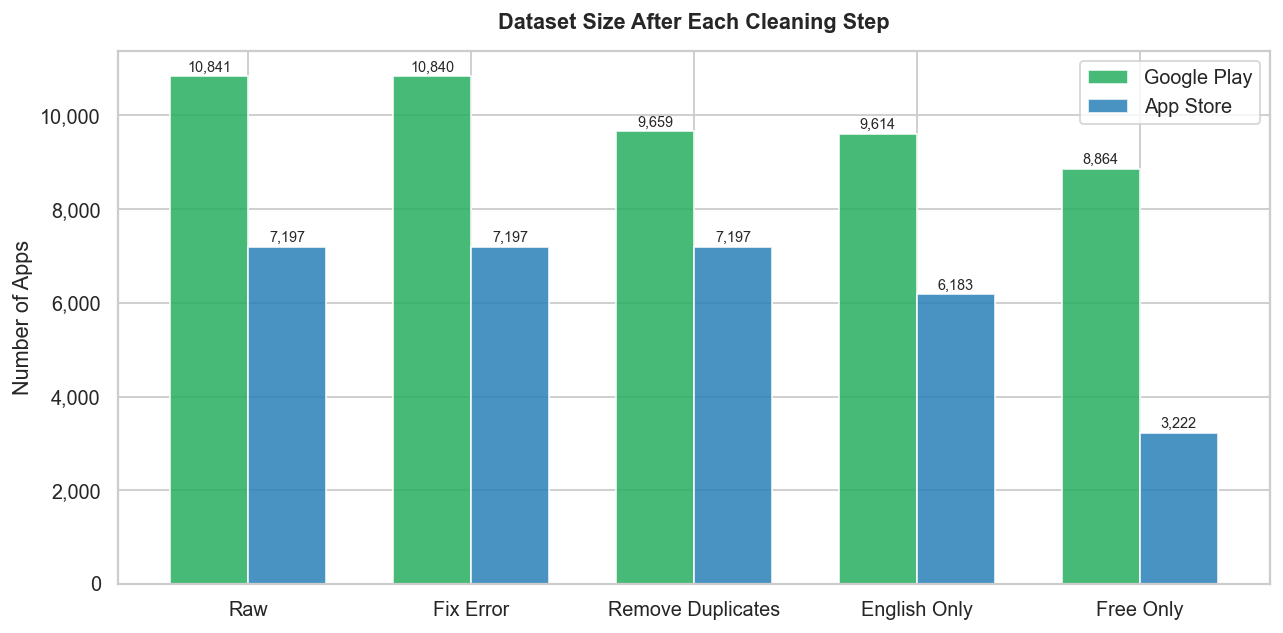

In [40]:
stages = ["Raw", "Fix Error", "Remove Duplicates", "English Only", "Free Only"]
android_counts = [10841, 10840, 9659, 9614, 8864]
ios_counts     = [7197,  7197,  7197, 6183, 3222]

x = range(len(stages))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - width/2 for i in x], android_counts, width,
               label="Google Play", color="#27ae60", alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], ios_counts, width,
               label="App Store", color="#2980b9", alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{bar.get_height():,}", ha="center", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{bar.get_height():,}", ha="center", fontsize=8)

ax.set_xticks(list(x))
ax.set_xticklabels(stages)
ax.set_ylabel("Number of Apps")
ax.set_title("Dataset Size After Each Cleaning Step", fontweight="bold", pad=12)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:,.0f}"))
plt.tight_layout()
plt.savefig("cleaning_pipeline.png", bbox_inches="tight")
plt.show()


## 6. Conclusions & Recommendation

### Key Findings

| Platform | Supply leader | Popularity leaders (genuine) | Skewed by giants |
|---|---|---|---|
| App Store | Games (58%) | Reference, Education | Navigation, Social, Music |
| Google Play | Family/Tools | Books & Reference, Education | Communication, Social, Video |

### ✅ Recommended App Profile: Interactive Book Companion

Both platforms point to the **Books & Reference** category as an underserved but genuinely popular niche. The market is not dominated by one unbeatable giant, meaning a well-crafted app can realistically earn a meaningful user base.

**Proposed concept:** Build an app around a popular book (fiction or non-fiction) and enrich it beyond the raw text:

- 📖 Daily quotes / highlights
- 🎧 Audio version with narration
- 🧠 Chapter quizzes
- 💬 Community discussion forum
- 📚 Built-in dictionary (no need to leave the app)

**Why this works:**
- App Store is saturated with games → a practical/educational app stands out
- Google Play's Books & Reference category has solid mid-tier install numbers (1M–50M range), showing real organic demand
- Content apps are cheap to build, easy to iterate, and scale well with in-app ads

**Validation strategy:**
1. Launch a minimal Android version on Google Play
2. Monitor user retention and rating growth over 90 days
3. If traction is confirmed → build iOS version and expand content library
